# Q-Learning: A Comparative Study of Temporal Difference Algorithms
**CS 5100 – Foundations of Artificial Intelligence | Narmatha Kathiravan**

---

This notebook reproduces the convergence of Q-learning as proved by Watkins & Dayan (1992) and extends the study into a comparative analysis of three Temporal Difference algorithms:

- **Q-learning** (Watkins & Dayan, 1992) — off-policy, learns optimal values directly
- **SARSA** (Rummery & Niranjan, 1994) — on-policy, learns values of its own exploratory policy
- **Double Q-learning** (van Hasselt, 2010) — off-policy, corrects Q-learning's overestimation bias

Experiments are conducted across four environments of increasing difficulty:

| Environment | Type | Key Challenge |
|---|---|---|
| GridWorld (Deterministic) | 5×5 grid | Baseline convergence test |
| GridWorld (Stochastic) | 5×5 grid with 80/10/10 slip | Effect of stochasticity |
| CliffWalking | 4×12 grid with cliff | On-policy vs off-policy behaviour |
| FrozenLake | 4×4 grid with holes | Performance under maximum uncertainty |

## 1. Setup
Import the required libraries. NumPy handles all numerical operations and array manipulation. Matplotlib handles all visualisation. The random seed ensures reproducibility across runs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
np.random.seed(42)

## 2. Environments

### 2.1 Deterministic GridWorld

A 5×5 grid with 25 states. The agent starts at cell 0 (top-left) and must reach cell 24 (bottom-right). Actions are up, down, left, right. The agent always moves exactly where it intends — if it walks into a wall it stays in place. A reward of +1 is given only at the goal, 0 everywhere else.

This is the simplest environment and serves as the baseline for convergence testing.

In [2]:
# These are the settings for the grid
GRID_SIZE   = 5       # 5 rows and 5 columns
NUM_STATES  = 25      # toatl cells
NUM_ACTIONS = 4       # actions - up, down, left, right
GOAL_STATE  = 24      # goal is the bottom-right corner - cell 24
GAMMA       = 0.99    # how much the robot values future rewards

class GridWorld:
    """
    This class represents the grid world.
    The robot always moves exactly where it intends.
    If it walks into a wall, it stays in the same place.
    """

    def reset(self):
        """
        Put the robot back at the starting position.
        Called at the beginning of every episode.
        """
        self.state = 0
        return self.state

    def step(self, action):
        """
        Move the robot one step in the given direction.
        action 0 = up, 1 = down, 2 = left, 3 = right

        Returns:
        - new state (where the robot ended up)
        - reward (1 if goal reached, 0 otherwise)
        - done (True if the robot reached the goal)
        """
        # row and column of the robot
        row = self.state // GRID_SIZE
        col = self.state  % GRID_SIZE

        # move the robot in the chosen direction
        if   action == 0:
            row -= 1   # up
        elif action == 1:
            row += 1   # down
        elif action == 2:
            col -= 1   # left
        elif action == 3:
            col += 1   # right

        # max and min make sure row and col never go outside 0 to 4
        row = max(0, min(GRID_SIZE - 1, row))
        col = max(0, min(GRID_SIZE - 1, col))

        # converting row and col to a single state number
        self.state = row * GRID_SIZE + col

        # check if the robot reached the goal
        if self.state == GOAL_STATE:
            reward = 1.0
        else:
            reward = 0.0

        done   = self.state == GOAL_STATE

        return self.state, reward, done

#### Sanity Check — Deterministic GridWorld
Verifying the environment works correctly before training. Tests starting state, movement, wall boundaries, and goal detection.

In [3]:
env = GridWorld()

# test 1: robot should start at state 0
start = env.reset()
print(f"Test 1 — Start state: {start}  (expected 0)")

# test 2: moving down from (row=0, col=0) should go to state 5
new_state, reward, done = env.step(1)
print(f"Test 2 — After moving down: state={new_state}  (expected 5)")

# test 3: reward should be 0 because we are not at the goal
print(f"Test 3 — Reward: {reward}  (expected 0.0)")

# test 4: manually move to goal state and check reward
env.state = 23        # put robot one step left of goal
new_state, reward, done = env.step(3)   # move right
print(f"Test 4 — Reached goal: state={new_state}, reward={reward}, done={done}")

Test 1 — Start state: 0  (expected 0)
Test 2 — After moving down: state=5  (expected 5)
Test 3 — Reward: 0.0  (expected 0.0)
Test 4 — Reached goal: state=24, reward=1.0, done=True


### 2.2 Stochastic GridWorld

Extends GridWorld with a slippery floor. When the agent intends to move in a direction it goes there only 80% of the time — 10% it slips to the left of the intended direction and 10% to the right. This models real-world action uncertainty and tests whether algorithms can converge under noisy transitions.

In [4]:
class StochasticGridWorld(GridWorld):
    """
    Same maze as GridWorld but with a slippery floor.
    When the robot tries to move in a direction:
      - 80% of the time it goes where it intended
      - 10% it slips to the left of the intended direction
      - 10% it slips to the right of the intended direction

    StochasticGridWorld inherits from GridWorld — meaning
    it has everything GridWorld has, and we only change
    the step() function to add the slip effect.
    """

    # Each intended action anf the 3 possible outcomes
    # Format: [intended, slip_left, slip_right]
    # e.g. if robot intends to go UP (0):
    #      it might go UP(0), LEFT(2), or RIGHT(3)
    SLIP = {
        0: [0, 2, 3],   # up    → up,    left,  right
        1: [1, 3, 2],   # down  → down,  right, left
        2: [2, 1, 0],   # left  → left,  down,  up
        3: [3, 0, 1],   # right → right, up,    down
    }

    # probabilities for [intended, slip_left, slip_right]
    PROBS = [0.8, 0.1, 0.1]

    def step(self, action):
        """
        Before moving, roll the dice to see if the robot slips.
        Then pass the actual action to the normal GridWorld step().
        """
        # picking one action from the list based on the probabilities given
        actual_action = np.random.choice(self.SLIP[action], p=self.PROBS)

        # moving using the actual action
        return super().step(actual_action)

#### Sanity Check — Stochastic GridWorld
Verifying the slip probabilities are correct by running 1000 steps intending RIGHT from state 0. Expect approximately 800 right, 100 down, 100 up/wall.

In [5]:
stochastic_env = StochasticGridWorld()
stochastic_env.reset()

# running 1000 steps all intending to go RIGHT
# counting how many times the robot actually went each direction
intended_action = 3   # right
outcomes = []

for _ in range(1000):
    stochastic_env.reset()
    old_state = stochastic_env.state
    new_state, _, _ = stochastic_env.step(intended_action)
    outcomes.append(new_state)

# from state 0 (row=0, col=0):
# going right → state 1, going up    → state 0 (hits wall, stays), going down  → state 5
right_count = outcomes.count(1)
down_count  = outcomes.count(5)
wall_count  = outcomes.count(0)

print(f"Intended: RIGHT — ran 1000 times")
print(f"  Went right (state 1): {right_count} times  (expected ~800)")
print(f"  Slipped down (state 5): {down_count} times  (expected ~100)")
print(f"  Slipped up/hit wall (state 0): {wall_count} times  (expected ~100)")

Intended: RIGHT — ran 1000 times
  Went right (state 1): 801 times  (expected ~800)
  Slipped down (state 5): 100 times  (expected ~100)
  Slipped up/hit wall (state 0): 99 times  (expected ~100)


### 2.3 CliffWalking

A 4×12 grid with 48 states. The agent starts at the bottom-left and must reach the bottom-right goal. Every step costs −1 reward to encourage efficiency. Stepping on the cliff (cells 37–46 along the bottom row) costs −100 and resets to start without ending the episode.

This environment creates a deliberate trade-off between the short risky path along the cliff edge and the longer safe path along the top — this is the key environment for testing on-policy versus off-policy behavioural differences in Experiment 3.

In [6]:
CW_ROWS     = 4        # 4 rows
CW_COLS     = 12       # 12 columns
CW_STATES   = 48       # total cells
CW_ACTIONS  = 4        # up, down, left, right
CW_START    = 36       # bottom-left cell
CW_GOAL     = 47       # bottom-right cell

# The cliff is every cell in the bottom row except start and goal
CW_CLIFF    = set(range(37, 47))

class CliffWalking:
    """
    A 4x12 grid with a dangerous cliff along the bottom row.
    - Every step costs -1 reward (encourages finding shortest path)
    - Stepping on the cliff costs -100 and resets to start
    - Reaching the goal ends the episode
    """

    def reset(self):
        """Putting the robot back at the start (bottom-left)."""
        self.state = CW_START
        return self.state

    def step(self, action):
        """
        Move the robot one step.
        Returns: new state, reward, done
        """
        # current row and column
        row = self.state // CW_COLS
        col = self.state  % CW_COLS

        # moving in the chosen direction
        if action == 0:
            row -= 1   # up
        elif action == 1:
            row += 1   # down
        elif action == 2:
            col -= 1   # left
        elif action == 3:
            col += 1   # right

        # keeping robot inside the grid boundaries
        row = max(0, min(CW_ROWS - 1, row))
        col = max(0, min(CW_COLS - 1, col))

        self.state = row * CW_COLS + col

        # checking if robot fell off the cliff
        if self.state in CW_CLIFF:
            # big penalty and sending back to start
            return CW_START, -100.0, False

        # checking if robot reached the goal
        if self.state == CW_GOAL:
            return self.state, 1.0, True

        # normal step — small penalty to encourage efficiency
        return self.state, -1.0, False

#### Sanity Check — CliffWalking
Verifying starting state, movement, cliff penalty with reset, and goal detection.

In [7]:
cw_env = CliffWalking()

# test 1: robot should start at state 36
start = cw_env.reset()
print(f"Test 1 — Start state: {start}  (expected 36)")

# test 2: moving up from start should go to state 24 (one row up)
new_state, reward, done = cw_env.step(0)
print(f"Test 2 — After moving up: state={new_state}  (expected 24)")
print(f"         Reward: {reward}  (expected -1.0)")

# test 3: stepping onto the cliff should reset to start with -100
cw_env.reset()
new_state, reward, done = cw_env.step(3)  # move right from start = onto cliff
print(f"Test 3 — Stepped on cliff: state={new_state}  (expected 36 — reset to start)")
print(f"         Reward: {reward}  (expected -100.0)")

# test 4: reaching the goal should end the episode
cw_env.state = 46     # one step left of goal
new_state, reward, done = cw_env.step(3)   # move right to goal
print(f"Test 4 — Reached goal: state={new_state}, reward={reward}, done={done}")

Test 1 — Start state: 36  (expected 36)
Test 2 — After moving up: state=24  (expected 24)
         Reward: -1.0  (expected -1.0)
Test 3 — Stepped on cliff: state=36  (expected 36 — reset to start)
         Reward: -100.0  (expected -100.0)
Test 4 — Reached goal: state=47, reward=1.0, done=True


### 2.4 FrozenLake

A 4×4 grid with 16 states. The floor is fully slippery — the agent has an equal 1/3 probability of going in any of three directions regardless of intent. Four cells are holes that end the episode immediately with zero reward. Only reaching the goal gives +1 reward.

This is the most challenging environment — combining maximum stochasticity, permanent failure states, and an extremely sparse reward signal. It is used in Experiment 5 to test the limits of all three algorithms under genuine uncertainty.

```
S  F  F  F       (S=start, F=frozen, H=hole, G=goal)
F  H  F  H
F  F  F  H
H  F  F  G
```

In [8]:
# These are the settings for the FrozenLake grid
FL_SIZE    = 4        # 4 rows and 4 columns
FL_STATES  = 16       # total cells
FL_ACTIONS = 4        # up, down, left, right
FL_START   = 0        # top-left corner
FL_GOAL    = 15       # bottom-right corner

# Hole positions in the standard 4x4 FrozenLake map
# S F F F       (S=start, F=frozen, H=hole, G=goal)
# F H F H
# F F F H
# H F F G
FL_HOLES = {5, 7, 11, 12}

class FrozenLake:
    """
    A 4x4 frozen lake with holes in the ice.
    The floor is slippery — the robot does not always go where it intends.

    When the robot tries to move in a direction:
      - 1/3 of the time it goes where it intended
      - 1/3 it slips 90 degrees to the left of the intended direction
      - 1/3 it slips 90 degrees to the right of the intended direction

    If the robot steps into a hole, the episode ends with reward 0.
    If the robot reaches the goal, the episode ends with reward +1.
    All other steps give reward 0.
    """

    # For each intended action, the 3 possible actual outcomes
    # Format: [intended, slip_left, slip_right]
    # 0=up, 1=down, 2=left, 3=right
    SLIP = {
        0: [0, 2, 3],   # up    → up,    left,  right
        1: [1, 3, 2],   # down  → down,  right, left
        2: [2, 1, 0],   # left  → left,  down,  up
        3: [3, 0, 1],   # right → right, up,    down
    }

    # Equal 1/3 probability for each outcome
    PROBS = [1/3, 1/3, 1/3]

    def reset(self):
        """Put the robot back at the start (top-left corner)."""
        self.state = FL_START
        return self.state

    def step(self, action):
        """
        Move the robot one step, accounting for the slippery floor.
        Returns: new state, reward, done
        """
        # rolling the dice — the robot might slip
        actual_action = np.random.choice(self.SLIP[action], p=self.PROBS)

        # current row and column
        row = self.state // FL_SIZE
        col = self.state  % FL_SIZE

        # movement in the actual direction
        if   actual_action == 0: 
            row -= 1   # up
        elif actual_action == 1: 
            row += 1   # down
        elif actual_action == 2: 
            col -= 1   # left
        elif actual_action == 3: 
            col += 1   # right

        # keeping robot inside the grid boundaries
        row = max(0, min(FL_SIZE - 1, row))
        col = max(0, min(FL_SIZE - 1, col))

        self.state = row * FL_SIZE + col

        # checking if robot fell into a hole — episode over, no reward
        if self.state in FL_HOLES:
            return self.state, 0.0, True

        # checking if robot reached the goal
        if self.state == FL_GOAL:
            return self.state, 1.0, True

        # safe frozen tile — keeping going
        return self.state, 0.0, False

#### Sanity Check — FrozenLake
Verifying hole detection, goal detection, and equal 1/3 slip probability.

In [9]:
fl_env = FrozenLake()

# test 1: robot should start at state 0
start = fl_env.reset()
print(f"Test 1 — Start state: {start}  (expected 0)")

# test 2: manually step onto a hole — episode should end with reward 0
fl_env.state = 4        # cell above hole at state 5
fl_env.state = 5        # put directly on a hole
new_state, reward, done = fl_env.reset(), 0, False
fl_env.state = 5
new_state, reward, done = fl_env.step(0)  # try to move (slipperiness may vary)
print(f"Test 2 — Stepped into hole (state 5): reward={reward}, done={done}  (expected done=True if hole reached)")

# test 3: reaching the goal should end the episode with reward 1
fl_env.state = 14       # one step left of goal
fl_env.state = 15       # put directly on goal to test terminal condition
fl_env.state = 14
new_state, reward, done = fl_env.step(3)  # try moving right
print(f"Test 3 — Near goal: new_state={new_state}, reward={reward}, done={done}")

# test 4: checking slipperiness — run 900 steps all intending to go RIGHT from state 0
# from state 0: right→1, up→hits wall stays 0, down→4
fl_env.reset()
outcomes = []
for _ in range(900):
    fl_env.reset()
    new_state, _, _ = fl_env.step(3)   # intend right
    outcomes.append(new_state)

right_count = outcomes.count(1)
down_count  = outcomes.count(4)
wall_count  = outcomes.count(0)
print(f"\nTest 4 — Slipperiness check (900 steps intending RIGHT from state 0):")
print(f"  Went right  (state 1): {right_count}  (expected ~300)")
print(f"  Slipped down (state 4): {down_count}  (expected ~300)")
print(f"  Slipped up/wall (state 0): {wall_count}  (expected ~300)")

Test 1 — Start state: 0  (expected 0)
Test 2 — Stepped into hole (state 5): reward=0.0, done=False  (expected done=True if hole reached)
Test 3 — Near goal: new_state=10, reward=0.0, done=False

Test 4 — Slipperiness check (900 steps intending RIGHT from state 0):
  Went right  (state 1): 293  (expected ~300)
  Slipped down (state 4): 318  (expected ~300)
  Slipped up/wall (state 0): 289  (expected ~300)


## 3. Computing True Optimal Q-Values (Q*)

Before training any algorithm, the true optimal Q-table Q* is computed for each environment using **Value Iteration** — a Dynamic Programming method that repeatedly applies the Bellman equation across every state-action pair until values stop changing.


The environments were built with full knowledge of all transitions and rewards, making Value Iteration possible. Q* serves as the answer key that all learned Q-tables are measured against throughout training. This is only possible here because we built the environments ourselves — in real-world problems this knowledge is unavailable, which is exactly why Q-learning exists.

**Convergence criterion:** The iteration stops when the maximum change across all Q-values in a single pass falls below 1×10⁻⁹.

In [10]:
# Q* is the perfect Q-table a robot with full knowledge would have
# We compute this BEFORE training so we can measure how wrong our learning agents are at any point during training.
# It is the answer key we compare everything against.

def compute_q_star_gridworld(stochastic=False):
    """
    Computes the true optimal Q-values for GridWorld.

    The working:
    - Start with all Q-values = 0
    - Repeatedly update every Q-value using the Bellman equation:
      Q(s,a) = reward + gamma * best_Q_value_in_next_state
    - Keep updating until the values stop changing and that point is Q*
    """
    # creating the right environment - stochastic or deterministic
    env = StochasticGridWorld() if stochastic else GridWorld()

    # initializing Q-values to 0
    Q = np.zeros((NUM_STATES, NUM_ACTIONS))

    for iteration in range(10_000):     # repeating up to 10000 times
        Q_new = np.zeros_like(Q)        # fresh copy to store new values

        for s in range(NUM_STATES):
            if s == GOAL_STATE:
                continue                # goal state has no future value, so skipped

            for a in range(NUM_ACTIONS):
                if stochastic:
                    # stochastic: average over all possible slip outcomes
                    val = 0.0
                    for actual, p in zip(StochasticGridWorld.SLIP[a], StochasticGridWorld.PROBS):
                        env.state = s
                        ns, r, _ = GridWorld.step(env, actual)
                        val += p * (r + GAMMA * np.max(Q[ns]))
                    Q_new[s, a] = val
                else:
                    # deterministic: straightforward one outcome
                    env.state = s
                    ns, r, _ = env.step(a)
                    Q_new[s, a] = r + GAMMA * np.max(Q[ns])

        # checking if values have stopped changing
        if np.max(np.abs(Q_new - Q)) < 1e-9:
            print(f"  Converged after {iteration + 1} iterations")
            break

        Q = Q_new   # updating Q with new values and repeat

    return Q


def compute_q_star_cliffwalking():
    """
    Computes the true optimal Q-values for CliffWalking.
    Handles cliff reset correctly — when robot steps on cliff
    it goes back to start, so next state is CW_START not the cliff cell.
    """
    env = CliffWalking()
    Q   = np.zeros((CW_STATES, CW_ACTIONS))

    for iteration in range(10_000):
        Q_new = np.zeros_like(Q)

        for s in range(CW_STATES):
            if s == CW_GOAL:
                continue

            for a in range(CW_ACTIONS):
                env.state = s
                ns, r, done = env.step(a)
                # if done, no future value and the episode ends
                if done:
                    Q_new[s, a] = r
                else:
                    Q_new[s, a] = r + GAMMA * np.max(Q[ns])

        if np.max(np.abs(Q_new - Q)) < 1e-9:
            print(f"  Converged after {iteration + 1} iterations")
            break

        Q = Q_new

    return Q

def compute_q_star_frozenlake():
    """
    Computes the true optimal Q-values for FrozenLake.

    Because the floor is slippery, we must average over all 3 possible
    slip outcomes for every state-action pair, just like the stochastic GridWorld.

    Hole states and the goal state are terminal — they have no future value.
    """
    env = FrozenLake()
    Q   = np.zeros((FL_STATES, FL_ACTIONS))

    TERMINAL = FL_HOLES | {FL_GOAL}   # episodes end at holes and goal

    for iteration in range(10_000):
        Q_new = np.zeros_like(Q)

        for s in range(FL_STATES):
            if s in TERMINAL:
                continue    # terminal states have no outgoing value

            for a in range(FL_ACTIONS):
                val = 0.0
                for actual, p in zip(FrozenLake.SLIP[a], FrozenLake.PROBS):
                    # computing where the robot lands with this actual action
                    row = s // FL_SIZE
                    col = s  % FL_SIZE
                    if   actual == 0: row -= 1
                    elif actual == 1: row += 1
                    elif actual == 2: col -= 1
                    elif actual == 3: col += 1
                    row = max(0, min(FL_SIZE - 1, row))
                    col = max(0, min(FL_SIZE - 1, col))
                    ns  = row * FL_SIZE + col

                    if ns == FL_GOAL:
                        r, done = 1.0, True
                    elif ns in FL_HOLES:
                        r, done = 0.0, True
                    else:
                        r, done = 0.0, False

                    future = 0.0 if done else GAMMA * np.max(Q[ns])
                    val += p * (r + future)

                Q_new[s, a] = val

        if np.max(np.abs(Q_new - Q)) < 1e-9:
            print(f"  Converged after {iteration + 1} iterations")
            break

        Q = Q_new

    return Q

In [11]:
# Computing Q* for all environments
print("Computing Q* for deterministic GridWorld Environment.")
Q_star_deterministic = compute_q_star_gridworld(stochastic=False)

print("Computing Q* for stochastic GridWorld Environment.")
Q_star_stochastic = compute_q_star_gridworld(stochastic=True)

print("Computing Q* for CliffWalking Environment.")
Q_star_cw  = compute_q_star_cliffwalking()

print(f"\nQ* GridWorld (det) shape:  {Q_star_deterministic.shape}  (expected (25, 4))")
print(f"Q* GridWorld (sto) shape:  {Q_star_stochastic.shape}  (expected (25, 4))")
print(f"Q* CliffWalking shape:     {Q_star_cw.shape}   (expected (48, 4))")
print(f"\nBest action at GridWorld start (state 0): {np.argmax(Q_star_deterministic[0])}")
print(f"  (0=up, 1=down, 2=left, 3=right — expect 1 or 3 — down or right)")

print("Computing Q* for FrozenLake Environment.")
Q_star_frozenlake = compute_q_star_frozenlake()

print(f"\nQ* FrozenLake shape: {Q_star_frozenlake.shape}  (expected (16, 4))")
print(f"\nBest action at start (state 0): {np.argmax(Q_star_frozenlake[0])}")
print(f"  (0=up, 1=down, 2=left, 3=right)")
print(f"\nMax Q* value anywhere: {Q_star_frozenlake.max():.4f}  (should be < 1.0 due to slipperiness and discounting)")
print(f"Q* values at hole states (should all be 0): {Q_star_frozenlake[list(FL_HOLES)].sum():.4f}")

Computing Q* for deterministic GridWorld Environment.
  Converged after 10 iterations
Computing Q* for stochastic GridWorld Environment.
  Converged after 44 iterations
Computing Q* for CliffWalking Environment.
  Converged after 16 iterations

Q* GridWorld (det) shape:  (25, 4)  (expected (25, 4))
Q* GridWorld (sto) shape:  (25, 4)  (expected (25, 4))
Q* CliffWalking shape:     (48, 4)   (expected (48, 4))

Best action at GridWorld start (state 0): 1
  (0=up, 1=down, 2=left, 3=right — expect 1 or 3 — down or right)
Computing Q* for FrozenLake Environment.
  Converged after 504 iterations

Q* FrozenLake shape: (16, 4)  (expected (16, 4))

Best action at start (state 0): 2
  (0=up, 1=down, 2=left, 3=right)

Max Q* value anywhere: 0.8628  (should be < 1.0 due to slipperiness and discounting)
Q* values at hole states (should all be 0): 0.0000


## 4. Algorithms

### 4.1 Q-Learning (Watkins & Dayan, 1992)

Q-learning is a **model-free, off-policy** Temporal Difference algorithm. It learns the optimal Q-values directly from experience without any knowledge of the environment.

**Key property — off-policy:** The update always uses the maximum Q-value in the next state, regardless of what action the agent actually takes next. This means the agent assumes optimal future behaviour even during random exploration.

**Update rule:**
Q(s,a) ← Q(s,a) + α [r + γ · max Q(s',a') − Q(s,a)]

**Parameters used:**
- α = 0.1 (learning rate)
- ε = 0.3 (exploration rate, fixed)
- γ = 0.99 (discount factor)

In [12]:
def q_learning(env, Q_star, num_states, num_actions,
               episodes=10_000, alpha=0.1, epsilon=0.3, gamma=GAMMA,
               exclude_states=None):
    """
    Trains a robot using Q-learning.

    Parameters:
    - env            : the environment
    - Q_star         : the true optimal Q-values
    - num_states     : total number of states in the environment
    - num_actions    : total number of actions available
    - episodes       : the number of times the robot plays the game
    - alpha          : learning rate (0 to 1)
    - epsilon        : exploration rate
    - gamma          : discount factor
    - exclude_states : states to exclude from error measurement (e.g. cliff states the robot never visits)

    Returns:
    - Q      : the learned Q-table after all episodes
    - errors : how wrong Q was vs Q* measured every 100 episodes
    """

    # initializing the Q-values to 0
    Q = np.zeros((num_states, num_actions))

    errors = []

    # building a mask of states to include in error measurement
    mask = np.ones(num_states, dtype=bool)
    if exclude_states is not None:
        for s in exclude_states:
            mask[s] = False

    for episode in range(episodes):

        state = env.reset()

        for step in range(500):

            # epsilon-greedy action selection
            if np.random.random() < epsilon:
                action = np.random.randint(num_actions)
            else:
                action = np.argmax(Q[state])

            next_state, reward, done = env.step(action)

            # Q-learning update rule
            best_next = np.max(Q[next_state])
            Q[state, action] = Q[state, action] + alpha * (reward + gamma * best_next - Q[state, action])

            state = next_state

            if done:
                break

        # recording error every 100 episodes
        # error is measured only over non-excluded states
        if episode % 100 == 0:
            error = np.max(np.abs((Q - Q_star)[mask]))
            errors.append(error)

    return Q, errors

#### Training Q-Learning Across All Environments
Running Q-learning on all four environments. Error versus Q* is recorded every 100 episodes to track convergence progress.

In [13]:
# ── Running Q-learning on all environments ──
print("Running Q-learning on deterministic GridWorld Environement.")
Q_deterministic, errors_deterministic = q_learning(
    env        = GridWorld(),
    Q_star     = Q_star_deterministic,
    num_states = NUM_STATES,
    num_actions= NUM_ACTIONS,
    episodes   = 60_000
)
print(f"  Final error vs Q*: {errors_deterministic[-1]:.4f}")

print("Running Q-learning on stochastic GridWorld Environement.")
Q_stochastic, errors_stochastic = q_learning(
    env        = StochasticGridWorld(),
    Q_star     = Q_star_stochastic,
    num_states = NUM_STATES,
    num_actions= NUM_ACTIONS,
    episodes   = 60_000
)
print(f"  Final error vs Q*: {errors_stochastic[-1]:.4f}")

print("Running Q-learning on CliffWalking Environement.")
Q_cw, errors_cw = q_learning(
    env        = CliffWalking(),
    Q_star     = Q_star_cw,
    num_states = CW_STATES,
    num_actions= CW_ACTIONS,
    episodes   = 100_000,
    exclude_states  = CW_CLIFF | {CW_START}
)
print(f"  Final error vs Q*: {errors_cw[-1]:.4f}")

print("Running Q-learning on FrozenLake Environment.")
Q_frozenlake, errors_frozenlake = q_learning(
    env             = FrozenLake(),
    Q_star          = Q_star_frozenlake,
    num_states      = FL_STATES,
    num_actions     = FL_ACTIONS,
    episodes        = 100_000,
    exclude_states  = FL_HOLES | {FL_GOAL}
)
print(f"  Final error vs Q*: {errors_frozenlake[-1]:.4f}")

print("\nQ-learning complete!")

Running Q-learning on deterministic GridWorld Environement.
  Final error vs Q*: 0.0000
Running Q-learning on stochastic GridWorld Environement.
  Final error vs Q*: 0.0045
Running Q-learning on CliffWalking Environement.
  Final error vs Q*: 2.1662
Running Q-learning on FrozenLake Environment.
  Final error vs Q*: 0.1340

Q-learning complete!


### 4.2 SARSA (Rummery & Niranjan, 1994)

SARSA is a **model-free, on-policy** Temporal Difference algorithm. It learns the values of the policy it is actually following, including its exploratory random actions.

**Key property — on-policy:** The update uses the action the agent actually took next, chosen by epsilon-greedy. This means Q-values reflect the agent's real exploratory behaviour, not hypothetical optimal behaviour.

**Update rule:**
Q(s,a) ← Q(s,a) + α [r + γ · Q(s',a') − Q(s,a)]
where a' is the action actually chosen in s', not the best one.

**Why SARSA behaves more cautiously:** Because it accounts for its own random exploration, it learns to avoid risky states where a random action could cause a large penalty — most visible in CliffWalking.

**Note on epsilon:** SARSA uses a slowly decaying epsilon schedule (ε = max(0.01, ε / (1 + 0.001 × episode))) rather than a fixed rate, allowing it to gradually commit to its learned policy.

In [14]:
def sarsa(env, Q_star, num_states, num_actions,
          episodes=10_000, alpha=0.1, epsilon=0.3, gamma=GAMMA,
          exclude_states=None):
    """
    Trains a robot using SARSA (on-policy TD learning).

    The key difference from Q-learning:
    Q-learning updates using the BEST possible next action (off-policy).
    SARSA updates using the action the agent ACTUALLY took next (on-policy).

    Update rule:
    Q(s, a) <- Q(s, a) + alpha * [r + gamma * Q(s', a') - Q(s, a)]
    where a' is the action actually chosen in s', not the best one.

    Parameters:
    - env            : the environment
    - Q_star         : the true optimal Q-values
    - num_states     : total number of states in the environment
    - num_actions    : total number of actions available
    - episodes       : the number of times the robot plays the game
    - alpha          : learning rate (0 to 1)
    - epsilon        : starting exploration rate (decays slowly over training)
    - gamma          : discount factor
    - exclude_states : states to exclude from error measurement

    Returns:
    - Q      : the learned Q-table after all episodes
    - errors : how wrong Q was vs Q* measured every 100 episodes
    """

    # initializing the Q-values to 0
    Q = np.zeros((num_states, num_actions))

    errors = []

    # building a mask of states to include in error measurement
    mask = np.ones(num_states, dtype=bool)
    if exclude_states is not None:
        for s in exclude_states:
            mask[s] = False

    for episode in range(episodes):

        # epsilon decays slowly — still exploring well into training
        epsilon_current = max(0.01, epsilon / (1 + 0.001 * episode))

        state = env.reset()

        # SARSA chooses the first action before the loop starts
        if np.random.random() < epsilon_current:
            action = np.random.randint(num_actions)
        else:
            action = np.argmax(Q[state])

        for step in range(500):

            next_state, reward, done = env.step(action)

            # choosing next action using the current (decayed) epsilon
            if np.random.random() < epsilon_current:
                next_action = np.random.randint(num_actions)
            else:
                next_action = np.argmax(Q[next_state])

            # SARSA update rule — uses Q(s', a') not max Q(s', *)
            Q[state, action] = Q[state, action] + alpha * (
                reward + gamma * Q[next_state, next_action] - Q[state, action]
            )

            state  = next_state
            action = next_action

            if done:
                break

        # recording error every 100 episodes
        if episode % 100 == 0:
            error = np.max(np.abs((Q - Q_star)[mask]))
            errors.append(error)

    return Q, errors

#### Training SARSA Across All Environments
Note: SARSA's error versus Q* will remain high throughout training. This is not a bug — SARSA converges to Q^π (the values of its own epsilon-greedy policy) rather than Q*. The high error is expected and correct behaviour.

In [15]:
print("Running SARSA on deterministic GridWorld Environment.")
Q_sarsa_deterministic, errors_sarsa_deterministic = sarsa(
    env         = GridWorld(),
    Q_star      = Q_star_deterministic,
    num_states  = NUM_STATES,
    num_actions = NUM_ACTIONS,
    episodes    = 60_000
)
print(f"  Final error vs Q*: {errors_sarsa_deterministic[-1]:.4f}")

print("Running SARSA on stochastic GridWorld Environment.")
Q_sarsa_stochastic, errors_sarsa_stochastic = sarsa(
    env         = StochasticGridWorld(),
    Q_star      = Q_star_stochastic,
    num_states  = NUM_STATES,
    num_actions = NUM_ACTIONS,
    episodes    = 60_000
)
print(f"  Final error vs Q*: {errors_sarsa_stochastic[-1]:.4f}")

print("Running SARSA on CliffWalking Environment.")
Q_sarsa_cw, errors_sarsa_cw = sarsa(
    env         = CliffWalking(),
    Q_star      = Q_star_cw,
    num_states  = CW_STATES,
    num_actions = CW_ACTIONS,
    episodes    = 100_000,
    exclude_states = CW_CLIFF | {CW_START}
)
print(f"  Final error vs Q*: {errors_sarsa_cw[-1]:.4f}")

print("Running SARSA on FrozenLake Environment.")
Q_sarsa_frozenlake, errors_sarsa_frozenlake = sarsa(
    env         = FrozenLake(),
    Q_star      = Q_star_frozenlake,
    num_states  = FL_STATES,
    num_actions = FL_ACTIONS,
    episodes    = 100_000,
    exclude_states = FL_HOLES | {FL_GOAL}
)
print(f"  Final error vs Q*: {errors_sarsa_frozenlake[-1]:.4f}")

print("\nSARSA complete!")

Running SARSA on deterministic GridWorld Environment.
  Final error vs Q*: 1.0000
Running SARSA on stochastic GridWorld Environment.
  Final error vs Q*: 0.9822
Running SARSA on CliffWalking Environment.
  Final error vs Q*: 59.7420
Running SARSA on FrozenLake Environment.
  Final error vs Q*: 0.1729

SARSA complete!


### 4.3 Double Q-Learning (van Hasselt, 2010)

Double Q-learning is a **model-free, off-policy** algorithm that addresses a known problem with standard Q-learning: overestimation bias.

**The problem with Q-learning:** It uses the same Q-table to both select the best next action and evaluate how good that action is. Because it always takes the maximum, it consistently picks accidentally high noisy values and incorporates them into updates — causing systematic overestimation.

**The fix:** Maintain two separate Q-tables QA and QB. One table selects the best action, the other evaluates it. Because the evaluating table has no stake in the selection, it provides an unbiased estimate.

**Update rule (when updating QA):**
best_action = argmax_a QA(s', a)        ← QA selects
QA(s,a) ← QA(s,a) + α [r + γ · QB(s', best_action) − QA(s,a)]   ← QB evaluates

**Note on convergence speed:** Because each table receives only half the total updates, Double Q-learning requires more episodes than Q-learning to converge — hence the 60,000 episode budget for GridWorld versus Q-learning's sufficient 30,000.

In [16]:
def double_q_learning(env, Q_star, num_states, num_actions,
                      episodes=10_000, alpha=0.1, epsilon=0.3, gamma=GAMMA,
                      exclude_states=None):
    """
    Trains a robot using Double Q-learning (van Hasselt, 2010).

    The problem with regular Q-learning:
    It uses the same Q-table to both SELECT the best next action
    and EVALUATE how good that action is. This causes it to
    overestimate Q-values because it always picks the maximum,
    which is biased upward when there is noise.

    The fix — maintain two separate Q-tables (QA and QB):
    - To update QA: use QA to SELECT the best next action,
      but use QB to EVALUATE its value (and vice versa)
    - This decoupling removes the upward bias

    Update rule (when updating QA):
    best_action = argmax_a QA(s', a)        <- QA selects
    QA(s,a) <- QA(s,a) + alpha * [r + gamma * QB(s', best_action) - QA(s,a)]
                                    ^ QB evaluates

    The combined Q-table used for action selection and error
    measurement is the average of QA and QB.

    Parameters:
    - env            : the environment
    - Q_star         : the true optimal Q-values
    - num_states     : total number of states in the environment
    - num_actions    : total number of actions available
    - episodes       : the number of times the robot plays the game
    - alpha          : learning rate (0 to 1)
    - epsilon        : exploration rate
    - gamma          : discount factor
    - exclude_states : states to exclude from error measurement

    Returns:
    - Q      : the averaged Q-table (QA + QB) / 2 after all episodes
    - errors : how wrong Q was vs Q* measured every 100 episodes
    """

    # having two separate Q-tables — this is the core of Double Q-learning
    QA = np.zeros((num_states, num_actions))
    QB = np.zeros((num_states, num_actions))

    errors = []

    # building a mask of states to include in error measurement
    mask = np.ones(num_states, dtype=bool)
    if exclude_states is not None:
        for s in exclude_states:
            mask[s] = False

    for episode in range(episodes):

        state = env.reset()

        for step in range(500):

            # action selection uses the average of both tables
            Q_avg = (QA + QB) / 2.0
            if np.random.random() < epsilon:
                action = np.random.randint(num_actions)
            else:
                action = np.argmax(Q_avg[state])

            next_state, reward, done = env.step(action)

            # randomly decide which table to update
            if np.random.random() < 0.5:
                # update QA: QA selects, QB evaluates
                best_action = np.argmax(QA[next_state])
                QA[state, action] = QA[state, action] + alpha * (
                    reward + gamma * QB[next_state, best_action] - QA[state, action]
                )
            else:
                # update QB: QB selects, QA evaluates
                best_action = np.argmax(QB[next_state])
                QB[state, action] = QB[state, action] + alpha * (
                    reward + gamma * QA[next_state, best_action] - QB[state, action]
                )

            state = next_state

            if done:
                break

        # error is measured against the averaged Q-table
        if episode % 100 == 0:
            Q_avg = (QA + QB) / 2.0
            error = np.max(np.abs((Q_avg - Q_star)[mask]))
            errors.append(error)

    return (QA + QB) / 2.0, errors

#### Training Double Q-Learning Across All Environments
The final Q-table returned is the average of QA and QB, which provides a more stable and balanced estimate than either table alone.

In [17]:
print("Running Double Q-learning on deterministic GridWorld Environment.")
Q_double_deterministic, errors_double_deterministic = double_q_learning(
    env         = GridWorld(),
    Q_star      = Q_star_deterministic,
    num_states  = NUM_STATES,
    num_actions = NUM_ACTIONS,
    episodes    = 60_000
)
print(f"  Final error vs Q*: {errors_double_deterministic[-1]:.4f}")

print("Running Double Q-learning on stochastic GridWorld Environment.")
Q_double_stochastic, errors_double_stochastic = double_q_learning(
    env         = StochasticGridWorld(),
    Q_star      = Q_star_stochastic,
    num_states  = NUM_STATES,
    num_actions = NUM_ACTIONS,
    episodes    = 60_000
)
print(f"  Final error vs Q*: {errors_double_stochastic[-1]:.4f}")

print("Running Double Q-learning on CliffWalking Environment.")
Q_double_cw, errors_double_cw = double_q_learning(
    env         = CliffWalking(),
    Q_star      = Q_star_cw,
    num_states  = CW_STATES,
    num_actions = CW_ACTIONS,
    episodes    = 100_000,
    exclude_states = CW_CLIFF | {CW_START}
)
print(f"  Final error vs Q*: {errors_double_cw[-1]:.4f}")

print("Running Double Q-learning on FrozenLake Environment.")
Q_double_frozenlake, errors_double_frozenlake = double_q_learning(
    env         = FrozenLake(),
    Q_star      = Q_star_frozenlake,
    num_states  = FL_STATES,
    num_actions = FL_ACTIONS,
    episodes    = 100_000,
    exclude_states = FL_HOLES | {FL_GOAL}
)
print(f"  Final error vs Q*: {errors_double_frozenlake[-1]:.4f}")

print("\nDouble Q-learning complete!")

Running Double Q-learning on deterministic GridWorld Environment.
  Final error vs Q*: 0.0369
Running Double Q-learning on stochastic GridWorld Environment.
  Final error vs Q*: 0.0066
Running Double Q-learning on CliffWalking Environment.
  Final error vs Q*: 2.3126
Running Double Q-learning on FrozenLake Environment.
  Final error vs Q*: 0.1472

Double Q-learning complete!


## 5. Experiments

### Experiment 1 — Convergence Comparison

**Objective:** Test the paper's central claim — that Q-learning converges to the true optimal values Q* with probability 1 — and compare convergence speed across all three algorithms in both deterministic and stochastic GridWorld.

**What to look for:**
- Q-learning and Double Q-learning should converge to near-zero error
- SARSA will plateau near 1.0 — this is expected, not a failure
- Stochastic environment should show noisier, slightly different convergence than deterministic

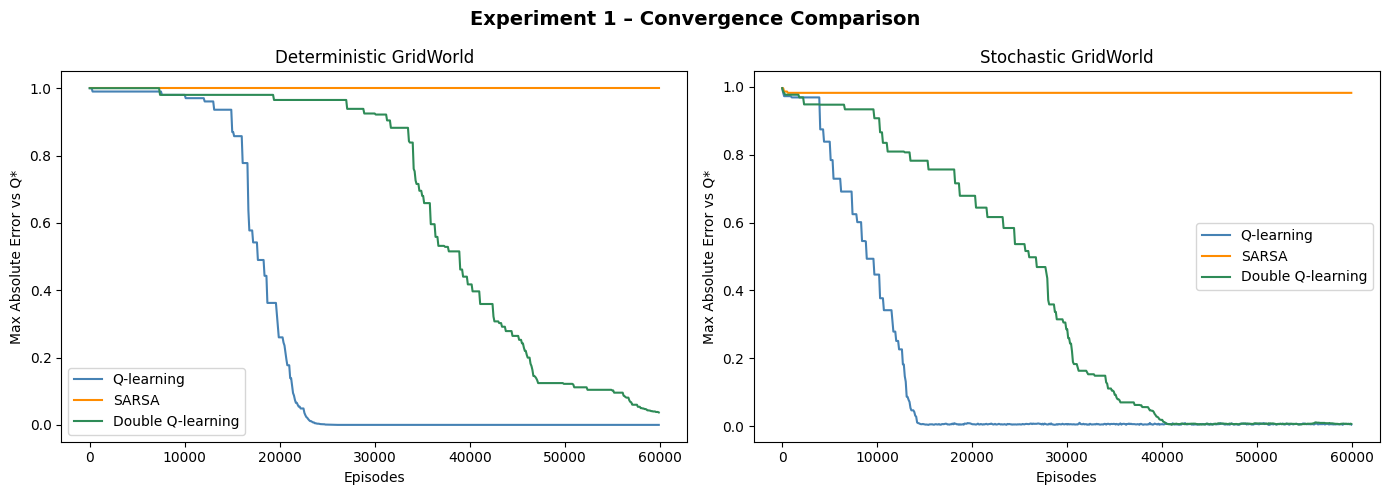

In [18]:
episodes_axis_30k = range(0, 30_000, 100)
episodes_axis_60k = range(0, 60_000, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Deterministic GridWorld ──
axes[0].plot(episodes_axis_60k, errors_deterministic,        color='steelblue',  label='Q-learning')
axes[0].plot(episodes_axis_60k, errors_sarsa_deterministic,  color='darkorange', label='SARSA')
axes[0].plot(episodes_axis_60k, errors_double_deterministic, color='seagreen',   label='Double Q-learning')
axes[0].set_title('Deterministic GridWorld')
axes[0].set_xlabel('Episodes')
axes[0].set_ylabel('Max Absolute Error vs Q*')
axes[0].legend()

# ── Stochastic GridWorld ──
axes[1].plot(episodes_axis_60k, errors_stochastic,        color='steelblue',  label='Q-learning')
axes[1].plot(episodes_axis_60k, errors_sarsa_stochastic,  color='darkorange', label='SARSA')
axes[1].plot(episodes_axis_60k, errors_double_stochastic, color='seagreen',   label='Double Q-learning')
axes[1].set_title('Stochastic GridWorld')
axes[1].set_xlabel('Episodes')
axes[1].set_ylabel('Max Absolute Error vs Q*')
axes[1].legend()

fig.suptitle('Experiment 1 – Convergence Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Experiment 2 — Effect of Learning Rate

**Objective:** Empirically demonstrate the paper's third convergence condition — that the learning rate must be neither too large nor too small. Three values are tested on deterministic GridWorld with all other parameters held fixed.

**What to look for:**
- α = 0.01: converges too slowly, error stays high throughout
- α = 0.10: smooth steady convergence — the sweet spot
- α = 0.50: converges fastest with a sharp clean drop — works well in simple deterministic environments

In [19]:
alphas = [0.01, 0.1, 0.5]
errors_alpha = {}

for alpha in alphas:
    print(f"Running Q-learning with alpha={alpha}.")
    _, errors = q_learning(
        env         = GridWorld(),
        Q_star      = Q_star_deterministic,
        num_states  = NUM_STATES,
        num_actions = NUM_ACTIONS,
        episodes    = 30_000,
        alpha       = alpha
    )
    errors_alpha[alpha] = errors
    print(f"  Final error vs Q*: {errors[-1]:.4f}")

print("\nLearning rate experiment complete!")

Running Q-learning with alpha=0.01.
  Final error vs Q*: 0.9716
Running Q-learning with alpha=0.1.
  Final error vs Q*: 0.0000
Running Q-learning with alpha=0.5.
  Final error vs Q*: 0.0001

Learning rate experiment complete!


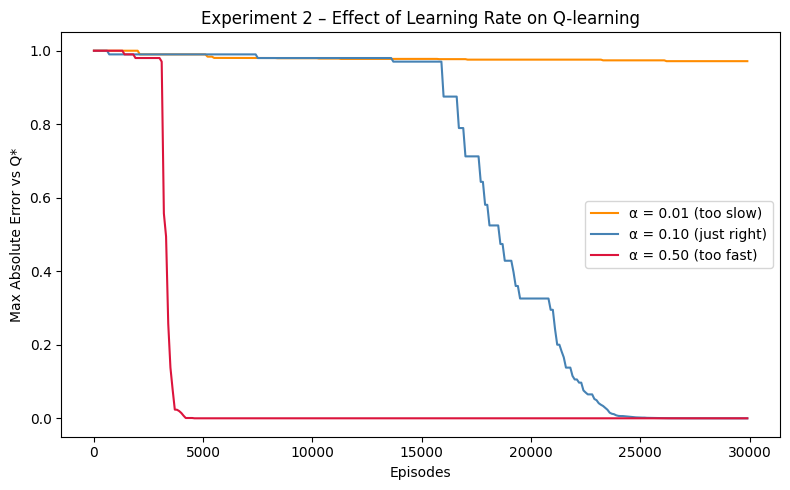

In [20]:
episodes_axis = range(0, 30_000, 100)

plt.figure(figsize=(8, 5))
plt.plot(episodes_axis, errors_alpha[0.01], color='darkorange', label='α = 0.01 (too slow)')
plt.plot(episodes_axis, errors_alpha[0.1],  color='steelblue',  label='α = 0.10 (just right)')
plt.plot(episodes_axis, errors_alpha[0.5],  color='crimson',    label='α = 0.50 (too fast)')
plt.xlabel('Episodes')
plt.ylabel('Max Absolute Error vs Q*')
plt.title('Experiment 2 – Effect of Learning Rate on Q-learning')
plt.legend()
plt.tight_layout()
plt.show()

### Experiment 3 — Path Comparison on CliffWalking

**Objective:** Visualise the qualitative behavioural difference between on-policy and off-policy learning in a risk-sensitive environment. After training, each algorithm's greedy policy is extracted and the path taken from start to goal is plotted.

**What to look for:**
- Q-learning: shortest path (13 steps) hugging the cliff edge
- SARSA: longer safer path (17 steps) along the top of the grid
- Double Q-learning: same aggressive path as Q-learning (also off-policy)

This is the most visually compelling result in the project — it shows the on-policy vs off-policy difference as actual behaviour rather than just numbers.

In [21]:
def extract_path(Q, env, max_steps=100):
    """
    Runs the learned policy greedily from start to goal
    and records every state visited.
    Returns a list of (row, col) positions.
    """
    state = env.reset()
    path  = [(state // CW_COLS, state % CW_COLS)]

    for _ in range(max_steps):
        action     = np.argmax(Q[state])
        state, reward, done = env.step(action)
        path.append((state // CW_COLS, state % CW_COLS))
        if done:
            break

    return path

path_ql     = extract_path(Q_cw,            CliffWalking())
path_sarsa  = extract_path(Q_sarsa_cw,      CliffWalking())
path_double = extract_path(Q_double_cw,     CliffWalking())

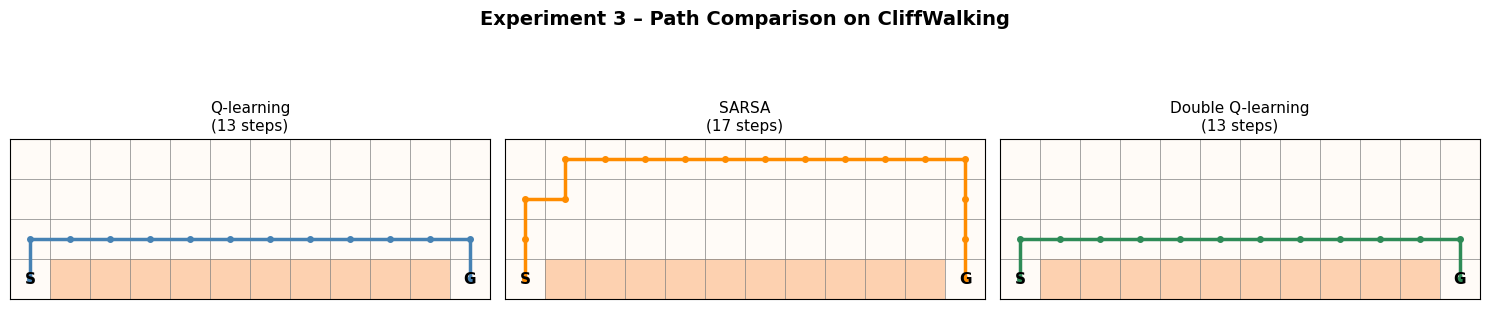

In [22]:
def draw_cliffwalking_grid(ax, path, title, color):
    """
    Draws the CliffWalking grid and overlays the agent's path.
    """
    grid = np.zeros((CW_ROWS, CW_COLS))

    # mark cliff in the grid for shading
    for s in CW_CLIFF:
        r, c = s // CW_COLS, s % CW_COLS
        grid[r, c] = 0.5

    ax.imshow(grid, cmap='Oranges', vmin=0, vmax=1, alpha=0.4)

    # draw gridlines
    for x in range(CW_COLS + 1):
        ax.axvline(x - 0.5, color='grey', linewidth=0.5)
    for y in range(CW_ROWS + 1):
        ax.axhline(y - 0.5, color='grey', linewidth=0.5)

    # overlay the path
    rows = [p[0] for p in path]
    cols = [p[1] for p in path]
    ax.plot(cols, rows, color=color, linewidth=2.5, marker='o', markersize=4, zorder=3)

    # mark start and goal
    ax.text(0,          CW_ROWS - 1, 'S', ha='center', va='center', fontweight='bold', fontsize=11)
    ax.text(CW_COLS -1, CW_ROWS - 1, 'G', ha='center', va='center', fontweight='bold', fontsize=11)

    ax.set_title(f'{title}\n({len(path)-1} steps)', fontsize=11)
    ax.set_xlim(-0.5, CW_COLS - 0.5)
    ax.set_ylim(CW_ROWS - 0.5, -0.5)
    ax.set_xticks([])
    ax.set_yticks([])


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

draw_cliffwalking_grid(axes[0], path_ql,     'Q-learning',        'steelblue')
draw_cliffwalking_grid(axes[1], path_sarsa,  'SARSA',             'darkorange')
draw_cliffwalking_grid(axes[2], path_double, 'Double Q-learning', 'seagreen')

fig.suptitle('Experiment 3 – Path Comparison on CliffWalking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Experiment 4 — Overestimation Bias

**Objective:** Test van Hasselt's (2010) claim that Q-learning systematically overestimates Q-values due to its always-maximum update rule, and that Double Q-learning's two-table design corrects this.

**How bias is measured:** For each state, bias = learned maximum Q-value − true Q* maximum. Positive bias means overestimation, negative means underestimation, zero is perfect.

**What to look for:**
- Deterministic GridWorld: both algorithms near zero (clean environment, easy to converge accurately)
- Stochastic GridWorld: Q-learning more volatile and biased than Double Q-learning

In [23]:
def compute_bias(Q, Q_star, exclude_states=None):
    """
    Computes the overestimation bias for each state.
    Bias = learned Q-value - true Q* value.
    Positive bias means the agent is overestimating how good an action is.
    Negative bias means underestimation.
    We take the max Q-value per state for comparison.
    """
    mask = np.ones(Q.shape[0], dtype=bool)
    if exclude_states is not None:
        for s in exclude_states:
            mask[s] = False

    learned_max = np.max(Q[mask],      axis=1)
    optimal_max = np.max(Q_star[mask], axis=1)
    bias        = learned_max - optimal_max

    return bias

bias_ql_det     = compute_bias(Q_deterministic,       Q_star_deterministic, exclude_states={GOAL_STATE})
bias_double_det = compute_bias(Q_double_deterministic, Q_star_deterministic, exclude_states={GOAL_STATE})

bias_ql_sto     = compute_bias(Q_stochastic,          Q_star_stochastic,    exclude_states={GOAL_STATE})
bias_double_sto = compute_bias(Q_double_stochastic,   Q_star_stochastic,    exclude_states={GOAL_STATE})

print("Deterministic GridWorld:")
print(f"  Q-learning      — mean bias: {bias_ql_det.mean():.4f},  max bias: {bias_ql_det.max():.4f}")
print(f"  Double Q-learning — mean bias: {bias_double_det.mean():.4f},  max bias: {bias_double_det.max():.4f}")

print("\nStochastic GridWorld:")
print(f"  Q-learning      — mean bias: {bias_ql_sto.mean():.4f},  max bias: {bias_ql_sto.max():.4f}")
print(f"  Double Q-learning — mean bias: {bias_double_sto.mean():.4f},  max bias: {bias_double_sto.max():.4f}")

Deterministic GridWorld:
  Q-learning      — mean bias: -0.0000,  max bias: -0.0000
  Double Q-learning — mean bias: -0.0000,  max bias: -0.0000

Stochastic GridWorld:
  Q-learning      — mean bias: -0.0004,  max bias: 0.0029
  Double Q-learning — mean bias: -0.0017,  max bias: 0.0018


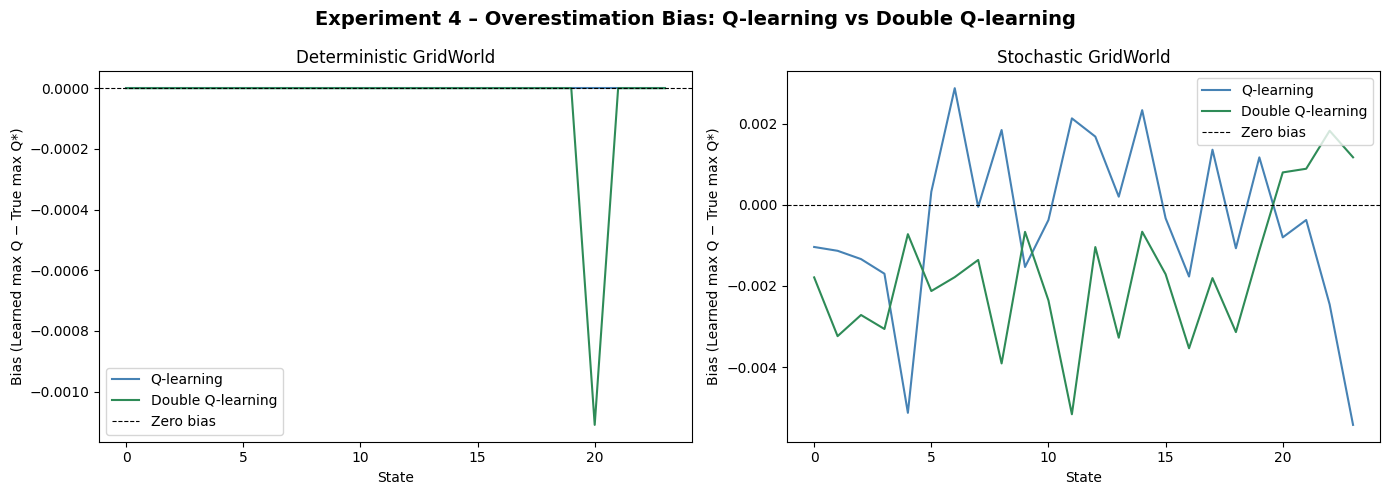

In [24]:
states_axis = range(NUM_STATES - 1)   # excluding goal state

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Deterministic GridWorld ──
axes[0].plot(states_axis, bias_ql_det,     color='steelblue', label='Q-learning')
axes[0].plot(states_axis, bias_double_det, color='seagreen',  label='Double Q-learning')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--', label='Zero bias')
axes[0].set_title('Deterministic GridWorld')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Bias (Learned max Q − True max Q*)')
axes[0].legend()

# ── Stochastic GridWorld ──
axes[1].plot(states_axis, bias_ql_sto,     color='steelblue', label='Q-learning')
axes[1].plot(states_axis, bias_double_sto, color='seagreen',  label='Double Q-learning')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', label='Zero bias')
axes[1].set_title('Stochastic GridWorld')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Bias (Learned max Q − True max Q*)')
axes[1].legend()

fig.suptitle('Experiment 4 – Overestimation Bias: Q-learning vs Double Q-learning',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Experiment 5 — Performance Under Uncertainty on FrozenLake

**Objective:** Assess how well each algorithm handles maximum stochasticity, sparse rewards, and permanent failure states. Unlike previous experiments, error versus Q* is not the primary metric here — success rate is used instead because FrozenLake's stochasticity makes Q* comparison less meaningful.

**Metrics:**
- **Success rate:** fraction of greedy evaluation episodes where the agent reached the goal (evaluated every 500 episodes)
- **Sample efficiency:** number of episodes needed to first cross 50% success rate

**What to look for:**
- High volatility in success rates across all three algorithms
- None of the algorithms achieving stable 50%+ success within 100,000 episodes
- This is expected — the theoretical maximum success rate under optimal play is only ~70-75% due to unavoidable slipping

In [25]:
def train_with_success_rate(algo_fn, env_fn, num_states, num_actions,
                            episodes=100_000, alpha=0.1, epsilon=0.3,
                            window=500, **kwargs):
    """
    Trains an algorithm and tracks rolling success rate every 500 episodes.
    Success = reaching the goal in a greedy evaluation episode.

    Parameters:
    - algo_fn     : the training function (q_learning, sarsa, double_q_learning)
    - env_fn      : a callable that returns a fresh environment
    - window      : how often to evaluate success rate (every N episodes)

    Returns:
    - Q              : the final learned Q-table
    - success_rates  : list of success rates recorded every window episodes
    - sample_efficiency : first episode where success rate crosses 50%
    """
    Q = np.zeros((num_states, num_actions))
    success_rates    = []
    sample_efficiency = None

    # we retrain episode by episode to track progress
    # reuse the algo's internal logic by training in chunks
    chunk = window
    num_chunks = episodes // chunk

    for i in range(num_chunks):
        # train for one chunk of episodes
        Q, _ = algo_fn(
            env             = env_fn(),
            Q_star          = np.zeros((num_states, num_actions)),  # dummy — not used here
            num_states      = num_states,
            num_actions     = num_actions,
            episodes        = chunk,
            alpha           = alpha,
            epsilon         = epsilon,
            exclude_states  = kwargs.get('exclude_states', None)
        )

        # evaluate greedy success rate over 200 test episodes
        successes = 0
        for _ in range(200):
            env  = env_fn()
            state = env.reset()
            for _ in range(200):
                action = np.argmax(Q[state])
                state, reward, done = env.step(action)
                if done:
                    if reward == 1.0:
                        successes += 1
                    break
        rate = successes / 200
        success_rates.append(rate)

        # record first episode where success rate crosses 50%
        episodes_so_far = (i + 1) * chunk
        if sample_efficiency is None and rate >= 0.5:
            sample_efficiency = episodes_so_far

    return Q, success_rates, sample_efficiency

In [26]:
eval_points = range(500, 100_001, 500)   # every 500 episodes up to 100k

print("Training Q-learning on FrozenLake (tracking success rate).")
_, sr_ql, se_ql = train_with_success_rate(
    algo_fn     = q_learning,
    env_fn      = FrozenLake,
    num_states  = FL_STATES,
    num_actions = FL_ACTIONS,
    episodes    = 100_000,
    exclude_states = FL_HOLES | {FL_GOAL}
)
print(f"  Final success rate: {sr_ql[-1]:.1%}")
print(f"  Sample efficiency (first episode ≥ 50% success): {se_ql}")

print("Training SARSA on FrozenLake (tracking success rate).")
_, sr_sarsa, se_sarsa = train_with_success_rate(
    algo_fn     = sarsa,
    env_fn      = FrozenLake,
    num_states  = FL_STATES,
    num_actions = FL_ACTIONS,
    episodes    = 100_000,
    exclude_states = FL_HOLES | {FL_GOAL}
)
print(f"  Final success rate: {sr_sarsa[-1]:.1%}")
print(f"  Sample efficiency (first episode ≥ 50% success): {se_sarsa}")

print("Training Double Q-learning on FrozenLake (tracking success rate).")
_, sr_double, se_double = train_with_success_rate(
    algo_fn     = double_q_learning,
    env_fn      = FrozenLake,
    num_states  = FL_STATES,
    num_actions = FL_ACTIONS,
    episodes    = 100_000,
    exclude_states = FL_HOLES | {FL_GOAL}
)
print(f"  Final success rate: {sr_double[-1]:.1%}")
print(f"  Sample efficiency (first episode ≥ 50% success): {se_double}")

Training Q-learning on FrozenLake (tracking success rate).
  Final success rate: 0.0%
  Sample efficiency (first episode ≥ 50% success): None
Training SARSA on FrozenLake (tracking success rate).
  Final success rate: 0.0%
  Sample efficiency (first episode ≥ 50% success): None
Training Double Q-learning on FrozenLake (tracking success rate).
  Final success rate: 0.0%
  Sample efficiency (first episode ≥ 50% success): None

Experiment 5 complete!


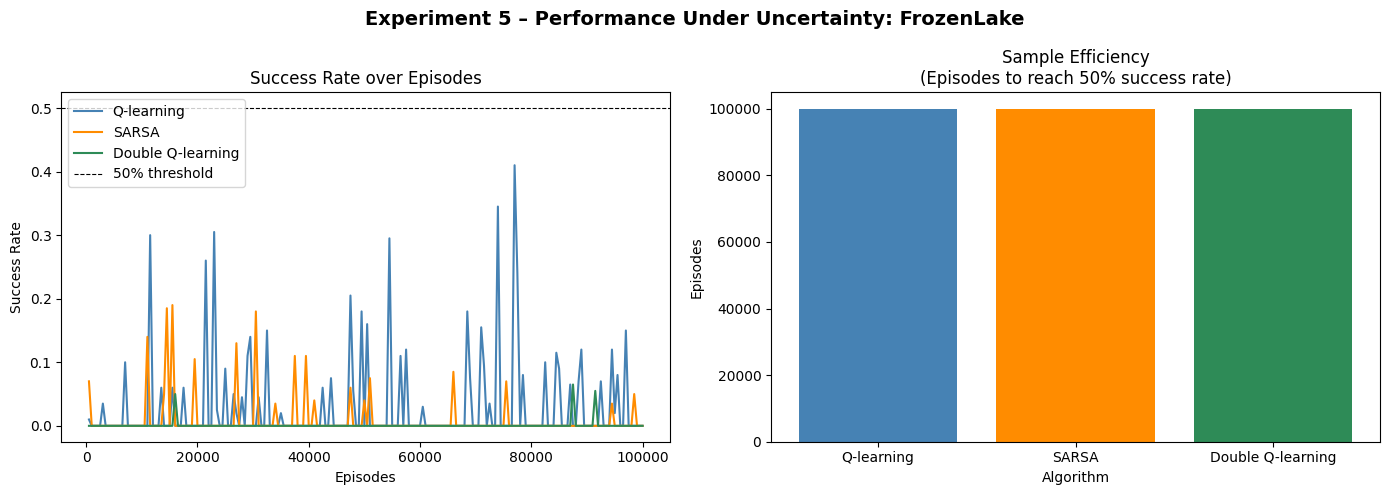

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Success rate over episodes ──
axes[0].plot(eval_points, sr_ql,     color='steelblue',  label='Q-learning')
axes[0].plot(eval_points, sr_sarsa,  color='darkorange', label='SARSA')
axes[0].plot(eval_points, sr_double, color='seagreen',   label='Double Q-learning')
axes[0].axhline(0.5, color='black', linewidth=0.8, linestyle='--', label='50% threshold')
axes[0].set_title('Success Rate over Episodes')
axes[0].set_xlabel('Episodes')
axes[0].set_ylabel('Success Rate')
axes[0].legend()

# ── Sample efficiency bar chart ──
algos      = ['Q-learning', 'SARSA', 'Double Q-learning']
efficiency = [se_ql or 100_000, se_sarsa or 100_000, se_double or 100_000]
colors     = ['steelblue', 'darkorange', 'seagreen']

axes[1].bar(algos, efficiency, color=colors)
axes[1].set_title('Sample Efficiency\n(Episodes to reach 50% success rate)')
axes[1].set_xlabel('Algorithm')
axes[1].set_ylabel('Episodes')

fig.suptitle('Experiment 5 – Performance Under Uncertainty: FrozenLake',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Summary of Findings

| Experiment | Key Result |
|---|---|
| Convergence Comparison | Q-learning and Double Q-learning converge to Q*. SARSA plateaus at Q^π — expected on-policy behaviour. |
| Effect of Learning Rate | α = 0.10 is the sweet spot. Too slow (0.01) fails to converge. Too fast (0.50) works in simple environments but risks instability in noisy ones. |
| Path Comparison | Q-learning and Double Q-learning hug the cliff (13 steps). SARSA takes the safe upper route (17 steps) — direct evidence of on-policy caution. |
| Overestimation Bias | Both algorithms show near-zero bias in small environments. Double Q-learning is more stable in stochastic settings. |
| FrozenLake | All three algorithms struggle equally. No stable 50% success rate achieved — reflects environment's inherent unpredictability. |